Primero hay que importar las librerías a utilizar

In [ ]:
!pip install keras-tuner --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 739.6 kB/s eta 0:00:00


In [ ]:
import os
import random
import shutil
from datetime import datetime
import time
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import unicodedata, re, os, random
from pathlib import Path
import tensorflow as tf
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, LSTM, Dropout
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, TerminateOnNaN
import keras_tuner as kt


In [ ]:
#url = 'http://walker.dgf.uchile.cl/Mediciones/datos/csv/D04T3.csv'
#df_met = pd.read_csv(url)
#df_met.head()
path = "/content/drive/MyDrive/Tesis/Base de datos/Datos_Tesis_SW.csv"
df = pd.read_csv(path)
df.head()

,Datetime,RotorSpeed,WindSpeed,PowerOutput,PitchDeg_Mean,temperature_2m,wind_speed_10m,wind_direction_10m,direct_radiation_instant,surface_pressure,relative_humidity_2m
0,2021-12-31 23:00:00,0.128476,0.010011,0.0,80.313994,5.90,1.868154,195.52417,0.0,967.39935,83.687060
1,2022-01-01 00:00:00,0.964534,0.140473,0.0,80.313994,6.30,2.308679,175.03035,0.0,967.57764,79.701300
2,2022-01-01 01:00:00,0.194438,0.070106,0.0,80.313994,5.95,3.505710,176.72958,0.0,968.06820,79.086890
3,2022-01-01 02:00:00,0.794549,0.052058,0.0,80.313994,5.60,3.423449,173.29025,0.0,967.80610,77.915985
4,2022-01-01 03:00:00,0.010484,0.002503,0.0,80.313994,5.10,1.824829,189.46225,0.0,967.79400,80.381100


In [ ]:
print("Datos originales:", len(df))
# Supongamos que tu dataframe es df con columnas 'Datetime' y 'WindSpeed'
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Definir fecha de corte
fecha_corte = pd.to_datetime("2023-01-01")

# Filtrar datos posteriores a esa fecha
df = df[df['Datetime'] >= fecha_corte].reset_index(drop=True)


print("Datos filtrados:", len(df))

Datos originales: 11912
Datos filtrados: 4626


In [ ]:
df.describe(include='all')

,Datetime,RotorSpeed,WindSpeed,PowerOutput,PitchDeg_Mean,temperature_2m,wind_speed_10m,wind_direction_10m,direct_radiation_instant,surface_pressure,relative_humidity_2m
count,4626,4626.000000,4626.000000,4626.000000,4626.000000,4626.000000,4626.000000,4626.000000,4626.000000,4626.000000,4626.000000
mean,2023-04-11 04:34:18.365758976,27.229682,2.745289,1.201070,25.318442,9.701762,2.843667,159.292720,102.355815,958.685655,74.354406
min,2023-01-01 00:00:00,0.000000,0.000000,-0.020264,14.034000,-7.150000,0.000000,2.202549,0.000000,926.156900,24.169455
25%,2023-02-19 16:15:00,0.594592,1.342490,0.000000,14.276026,3.450000,1.667325,58.240574,0.000000,955.182920,63.181031
50%,2023-04-11 21:30:00,26.911270,2.186670,0.281569,20.497263,8.700000,2.647640,180.000000,0.000000,958.656585,77.483625
75%,2023-05-31 07:45:00,47.283270,3.672989,1.509199,37.858940,15.787500,3.780212,236.309900,118.246460,962.245240,88.095120
max,2023-07-20 21:00:00,65.896111,14.124165,6.877236,80.708735,33.550000,9.481033,360.000000,789.811400,977.910160,100.000000
std,NaN,22.953260,2.053437,1.865368,12.442259,8.173672,1.549056,93.105616,184.785176,7.233962,16.504555


In [ ]:
df['Datetime'] = pd.to_datetime(df['Datetime'])
df['Dia Juliano'] = df['Datetime'].apply(lambda x: x.toordinal())
df.drop(columns=['wind_speed_10m', 'RotorSpeed','PowerOutput', 'PitchDeg_Mean'], inplace=True)
#df.drop(columns=['RotorSpeed','PowerOutput', 'PitchDeg_Mean'], inplace=True)
df.describe()

,Datetime,WindSpeed,temperature_2m,wind_direction_10m,direct_radiation_instant,surface_pressure,relative_humidity_2m,Dia Juliano
count,4626,4626.000000,4626.000000,4626.000000,4626.000000,4626.000000,4626.000000,4626.000000
mean,2023-04-11 04:34:18.365758976,2.745289,9.701762,159.292720,102.355815,958.685655,74.354406,738620.717250
min,2023-01-01 00:00:00,0.000000,-7.150000,2.202549,0.000000,926.156900,24.169455,738521.000000
25%,2023-02-19 16:15:00,1.342490,3.450000,58.240574,0.000000,955.182920,63.181031,738570.000000
50%,2023-04-11 21:30:00,2.186670,8.700000,180.000000,0.000000,958.656585,77.483625,738621.000000
75%,2023-05-31 07:45:00,3.672989,15.787500,236.309900,118.246460,962.245240,88.095120,738671.000000
max,2023-07-20 21:00:00,14.124165,33.550000,360.000000,789.811400,977.910160,100.000000,738721.000000
std,NaN,2.053437,8.173672,93.105616,184.785176,7.233962,16.504555,58.278738


In [ ]:
print("Datos originales:", len(df))
# Supongamos que tu dataframe es df con columnas 'Datetime' y 'WindSpeed'
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Definir fecha de corte
fecha_corte = pd.to_datetime("2023-01-01")

# Filtrar datos posteriores a esa fecha
df = df[df['Datetime'] >= fecha_corte].reset_index(drop=True)


print("Datos filtrados:", len(df))

Datos originales: 4626
Datos filtrados: 4626


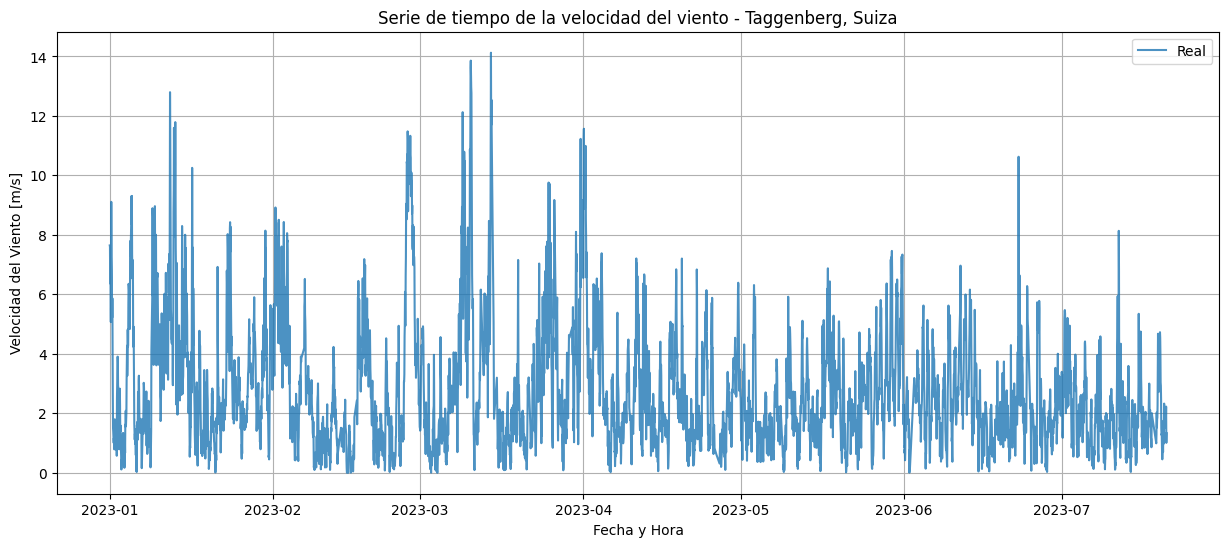

In [ ]:
plt.figure(figsize=(15, 6))
plt.plot(df['Datetime'], df['WindSpeed'], label='Real', alpha=0.8)
plt.title(f'Serie de tiempo de la velocidad del viento - Taggenberg, Suiza')
plt.xlabel('Fecha y Hora')
plt.ylabel('Velocidad del Viento [m/s]')
plt.legend()
plt.grid(True)
plt.show()

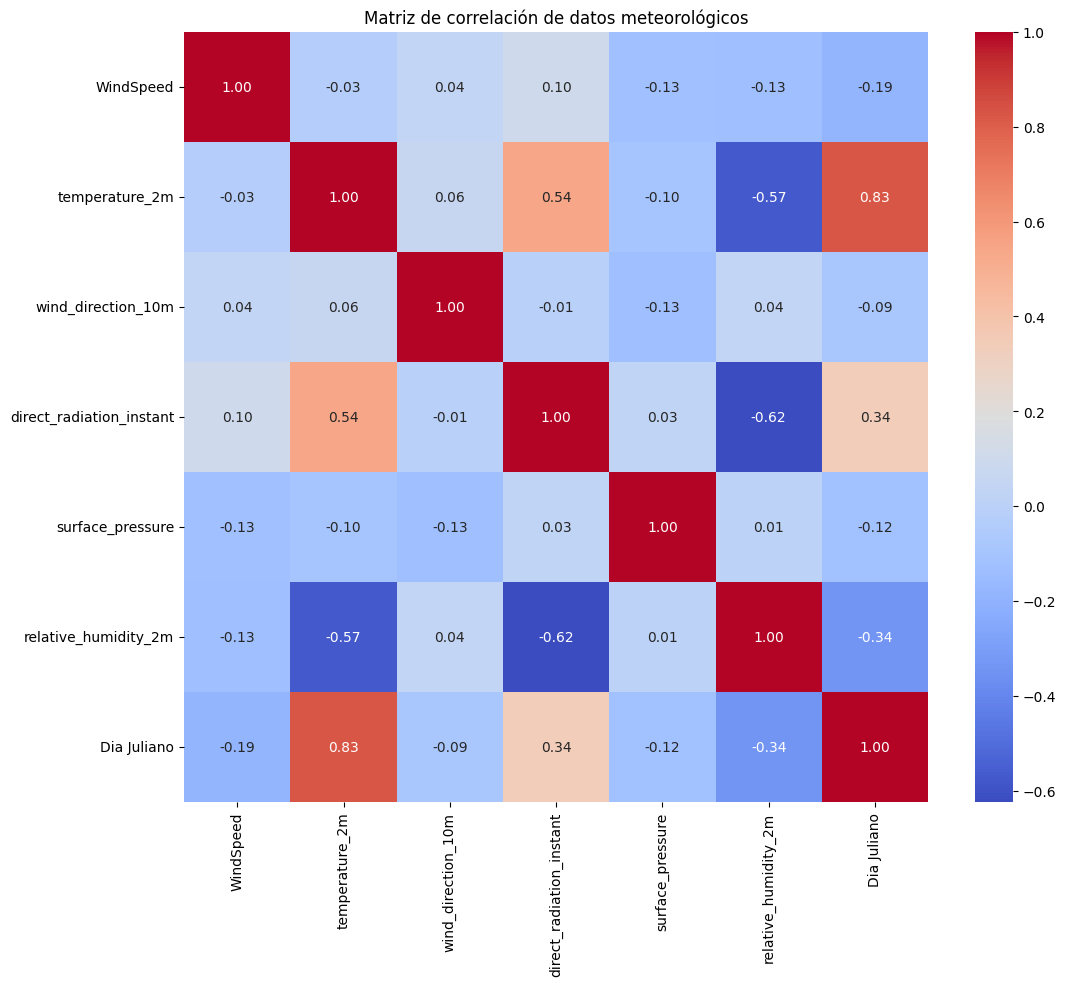

In [ ]:
df['Datetime'] = pd.to_datetime(df['Datetime'])
df.set_axis(df['Datetime'])
df.drop(columns=['Datetime'], inplace=True)

correlation_matrix = df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de correlación de datos meteorológicos')
plt.show()

## Regresión Lineal Múltiple
A continuación se empleará un modelo de regresión lineal múltiple con el fin de verificar si se puede modelar como relaciones lineales, lo cual sabemos por estudios que el viento es aleatorio y no se mueve linealmente. Esto es para saber las variables significativas linealmente y para dar inicio a análisis más avanzados como ramdon forest para ver relaciones no lineales y luego empezar con el modelo de predicción.

In [ ]:
dependent_variable = 'WindSpeed'
independent_variables = [col for col in df.columns if col not in ['Datetime', 'RotorSpeed', 'PowerOutput', 'PitchDeg_Mean', dependent_variable]]
X = df[independent_variables]
X = sm.add_constant(df[independent_variables])
y = df[dependent_variable]
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              WindSpeed   R-squared:                       0.125
Model:                            OLS   Adj. R-squared:                  0.124
Method:                 Least Squares   F-statistic:                     110.2
Date:                Wed, 04 Mar 2026   Prob (F-statistic):          2.67e-130
Time:                        12:50:49   Log-Likelihood:                -9582.5
No. Observations:                4626   AIC:                         1.918e+04
Df Residuals:                    4619   BIC:                         1.922e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

In [ ]:
independent_variables = [col for col in df.columns if col not in ['Generación PE TALTAL (MWh)', 'Velocidad de viento en 110.0 metros [mean,m/s]']]

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]


print("Variance Inflation Factor (VIF) for Independent Variables:")
print(vif_data)

Variance Inflation Factor (VIF) for Independent Variables:
                    feature           VIF
0                     const  6.126780e+08
1            temperature_2m  5.248214e+00
2        wind_direction_10m  1.119608e+00
3  direct_radiation_instant  1.821920e+00
4          surface_pressure  1.043362e+00
5      relative_humidity_2m  1.985908e+00
6               Dia Juliano  3.811216e+00


# Modelos

# Modelo predictivo

## Long Short Term Memory (LSTM)

In [ ]:
def create_sequences_with_dates(X, y, dates, time_steps):
    Xs, ys, seq_dates = [], [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
        seq_dates.append(dates.iloc[i + time_steps])
    return np.array(Xs), np.array(ys), np.array(seq_dates)

# Reproducibility
os.environ['PYTHONHASHSEED']='0'
os.environ['TF_DETERMINISTIC_OPS']='1'
seed=42
random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)

dependent_variable = 'wind_speed_10m'
independent_variables = [col for col in df.columns if col not in ['Datetime', 'RotorSpeed', 'PowerOutput', 'PitchDeg_Mean', dependent_variable]]

X = df[independent_variables].values
y = df[dependent_variable].values
dates = pd.to_datetime(df['Datetime'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

window_sizes = [1, 3, 6, 24, 48, 72]
all_models_results = [] # Initialize empty list for results

# --- LOOP TO TEST DIFFERENT WINDOW SIZES ---
for time_steps in window_sizes:
    print(f"\n Training model with window of {time_steps} hours...")

    # Create sequences
    X_seq, y_seq, seq_dates = create_sequences_with_dates(X_scaled, y, dates, time_steps)

    # Temporal split (without shuffle)
    train_size = int(len(X_seq) * 0.7)
    val_size = int(len(X_seq) * 0.15)
    test_start = train_size + val_size

    # Clean and assign
    X_train, X_val, X_test = X_seq[:train_size], X_seq[train_size:test_start], X_seq[test_start:]
    y_train, y_val, y_test = y_seq[:train_size], y_seq[train_size:test_start], y_seq[test_start:]
    date_test = seq_dates[test_start:]

    # --- OPTIMIZER CONFIGURATION ---
    initial_lr = 0.001  # initial learning rate
    optimizer = Adam(learning_rate=initial_lr)

   # --- CALLBACKS ---
    lrS = ReduceLROnPlateau(
        monitor='val_loss', factor=0.2, patience=20, min_lr=1e-6, verbose=1
    )
    eS = EarlyStopping(
        monitor='val_loss', patience=50, min_delta=1e-6, restore_best_weights=True, verbose=1
    )
    #mc = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)
    tN = TerminateOnNaN()

    # --- MODELO LSTM ---
    #Variar cantidad de neuronas
    model = Sequential([
        LSTM(64, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2])),
        Dropout(0.6),
        Dense(1)
    ])
    model.compile(optimizer=optimizer, loss='mse')

    # --- TRAINING ---
    history = model.fit(
        X_train, y_train,
        epochs=300,
        batch_size=32,
        validation_data=(X_val, y_val),
        callbacks=[eS, tN, lrS],
        shuffle = False,
        verbose=0 # Changed to 0 to avoid verbose output for each epoch
    )

    # --- PREDICTIONS ---
    y_pred = model.predict(X_test).flatten()

    # --- METRICS ---
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # --- GET MODEL WEIGHTS ---
    model_weights = model.get_weights()

    # --- STORE RESULTS ---
    all_models_results.append({
        'window_size': time_steps,
        'MSE': mse,
        'MAE': mae,
        'R2': r2,
        'y_pred': y_pred,
        'y_test': y_test,
        'date_test': date_test,
        'model_weights': model_weights
    })

    print(f" Window {time_steps}h \u2192 MSE: {mse:.4f} | MAE: {mae:.4f} | R²: {r2:.3f}")




 Training model with window of 1 hours...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Restoring model weights from the end of the best epoch: 300.
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
 Window 1h → MSE: 1.3292 | MAE: 0.9327 | R²: 0.142

 Training model with window of 3 hours...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Epoch 91: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.

Epoch 115: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.

Epoch 135: ReduceLROnPlateau reducing learning rate to 8.000000525498762e-06.
Epoch 145: early stopping
Restoring model weights from the end of the best epoch: 95.
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
 Window 3h → MSE: 1.2337 | MAE: 0.8938 | R²: 0.204

 Training model with window of 6 hours...


...


Epoch 59: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.

Epoch 79: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.
Epoch 89: early stopping
Restoring model weights from the end of the best epoch: 39.
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
 Window 24h → MSE: 1.2475 | MAE: 0.8978 | R²: 0.195

 Training model with window of 48 hours...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Epoch 54: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.

Epoch 74: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.
Epoch 84: early stopping
Restoring model weights from the end of the best epoch: 34.
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
 Window 48h → MSE: 1.1133 | MAE: 0.8465 | R²: 0.283

 Training model with window of 72 hours...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Epoch 63: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.

Epoch 86: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.

Epoch 106: ReduceLROnPlateau reducing learning rate to 8.000000525498762e-06.
Epoch 116: early stopping
Restoring model weights from the end of the best epoch: 66.
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
 Window 72h → MSE: 1.1561 | MAE: 0.8557 | R²: 0.257


In [ ]:
# --- FINAL SUMMARY OF RESULTS ---
print("\n GLOBAL RESULTS (all_models_results list contains detailed data)")
for res in all_models_results:
    print(f"Window {res['window_size']}h: MSE={res['MSE']:.4f}, MAE={res['MAE']:.4f}, R²={res['R2']:.3f}")

# Optionally, save all_models_results to a file if needed
import joblib
joblib.dump(all_models_results, '/content/drive/MyDrive/Tesis/Output/all_models_results_SW.pkl')

In [ ]:
import joblib
from pathlib import Path

# Define the path to the output directory, correcting the emoji
OUTPUT_DIR = Path('/content/drive/MyDrive/Tesis/Output')

# Define the path to the all_models_results.pkl file
pkl_file_path = OUTPUT_DIR / 'all_models_results_SW.pkl'

# Load the all_models_results.pkl file
all_models_results = joblib.load(pkl_file_path)

print(f"All model results loaded successfully from: {pkl_file_path}")

# Display the first few elements of the list to inspect its structure and content
print("\nFirst 2 elements of all_models_results:")
for i, res in enumerate(all_models_results[:2]):
    print(f"\nElement {i+1}:")
    # Print only key metrics and window size to keep output concise
    print(f"  window_size: {res['window_size']}")
    print(f"  MSE: {res['MSE']:.4f}")
    print(f"  MAE: {res['MAE']:.4f}")
    print(f"  R2: {res['R2']:.3f}")
    print(f"  Length of y_pred: {len(res['y_pred'])}")
    print(f"  Length of y_test: {len(res['y_test'])}")
    print(f"  Length of date_test: {len(res['date_test'])}")

All model results loaded successfully from: /content/drive/MyDrive/Tesis/Output/all_models_results_SW.pkl

First 2 elements of all_models_results:

Element 1:
  window_size: 1
  MSE: 1.3292
  MAE: 0.9327
  R2: 0.142
  Length of y_pred: 1788
  Length of y_test: 1788
  Length of date_test: 1788

Element 2:
  window_size: 3
  MSE: 1.2337
  MAE: 0.8938
  R2: 0.204
  Length of y_pred: 1787
  Length of y_test: 1787
  Length of date_test: 1787


In [ ]:
best_r2 = -float('inf')
best_mae = float('inf')
best_model_info = None

for model_result in all_models_results:
    current_r2 = model_result['R2']
    current_mae = model_result['MAE']

    # Prioritize R2, then MAE
    if current_r2 > best_r2:
        best_r2 = current_r2
        best_mae = current_mae
        best_model_info = model_result
    elif current_r2 == best_r2 and current_mae < best_mae:
        best_mae = current_mae
        best_model_info = model_result

print("\nBest performing model:")
if best_model_info:
    print(f"  Window Size: {best_model_info['window_size']} hours")
    print(f"  R2: {best_model_info['R2']:.3f}")
    print(f"  MAE: {best_model_info['MAE']:.4f}")
    print(f"  MSE: {best_model_info['MSE']:.4f}")
else:
    print("No model information found.")


Best performing model:
  Window Size: 48 hours
  R2: 0.283
  MAE: 0.8465
  MSE: 1.1133


In [ ]:
import pandas as pd
from pathlib import Path
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense


# Ensure the output directory exists
OUTPUT_DIR = Path('/content/drive/MyDrive/Tesis/Output')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

excel_output_path = OUTPUT_DIR / 'LSTM_Predictions_All_Windows_SW.xlsx'

# Create a Pandas Excel writer using XlsxWriter as the engine.
# This allows writing to multiple sheets within a single Excel file.
with pd.ExcelWriter(excel_output_path, engine='xlsxwriter') as writer:
    for model_result in all_models_results:
        window_size = model_result['window_size']
        y_pred = model_result['y_pred']
        y_test = model_result['y_test']
        date_test = model_result['date_test']

        # Create a DataFrame for the current window's predictions
        df_predictions = pd.DataFrame({
            'Datetime': date_test,
            'wind_speed_10m': y_test,
            'wind_speed_10m_pred': y_pred
        })

        # Save to a sheet named after the window size
        sheet_name = f'Window_{window_size}h'
        df_predictions.to_excel(writer, sheet_name=sheet_name, index=False)

print(f"All LSTM predictions saved to: {excel_output_path}")

def create_sequences_for_best_model(X, y, time_steps):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

# Scale X again to ensure correct shape for create_sequences_for_best_model
scaler = StandardScaler()
X_scaled_for_best = scaler.fit_transform(df[independent_variables].values)

# Create sequences for the best window size to get the input shape
X_seq_best, _ = create_sequences_for_best_model(X_scaled_for_best, y, best_model_info['window_size'])

best_model = Sequential([
    LSTM(64, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.6),
    Dense(1)
])

# Set the weights for the best model
best_model.set_weights(best_model_info['model_weights'])

# Save the weights of the best performing model
best_weights_path = OUTPUT_DIR / 'best_lstm_model_SW_weights.weights.h5'
best_model.save_weights(best_weights_path)

print(f"Best model weights saved to: {best_weights_path}")

All LSTM predictions saved to: /content/drive/MyDrive/Tesis/Output/LSTM_Predictions_All_Windows_SW.xlsx
Best model weights saved to: /content/drive/MyDrive/Tesis/Output/best_lstm_model_SW_weights.weights.h5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
OUTPUT_DIR = Path('/content/drive/MyDrive/Tesis/Output')
output_file_path_csv = OUTPUT_DIR / 'Predicciones_full_data_SW.csv'
df_full_predictions.to_csv(output_file_path_csv, index=False)
print(f"DataFrame df_full_predictions guardado en: {output_file_path_csv}")

DataFrame df_full_predictions guardado en: /content/drive/MyDrive/Tesis/Output/Predicciones_full_data_SW.csv


In [ ]:
output_file_path_excel = OUTPUT_DIR / 'Predicciones_6h.xlsx'
df_full_predictions.to_excel(output_file_path_excel, index=False)
print(f"DataFrame df_full_predictions guardado en: {output_file_path_excel}")

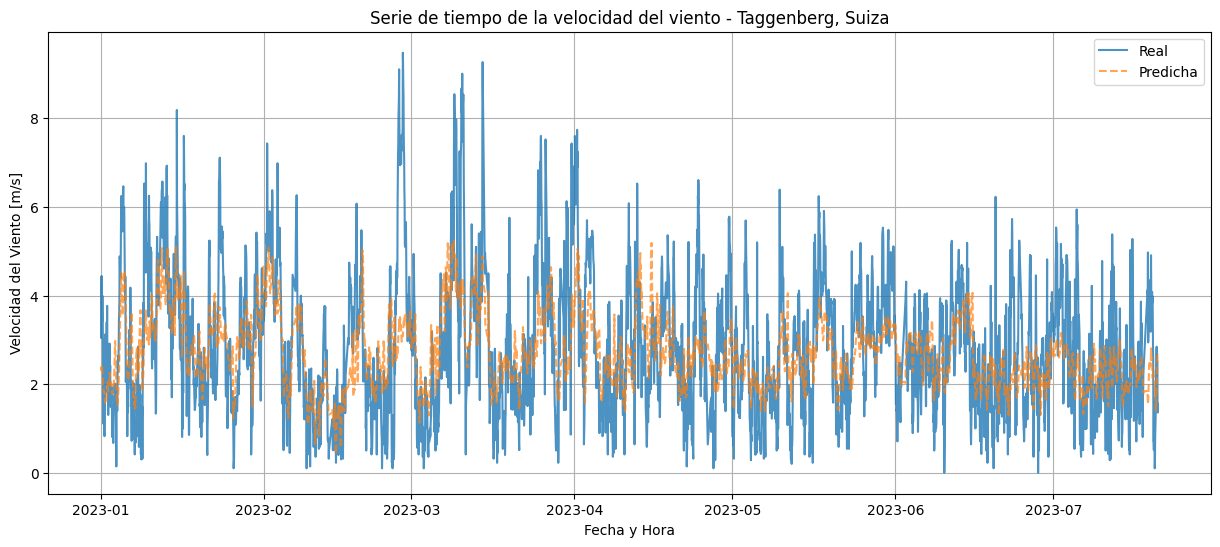

In [ ]:
plt.figure(figsize=(15, 6))
plt.plot(df['Datetime'], df['wind_speed_10m'], label='Real', alpha=0.8)
plt.plot(df['Datetime'], df['pred_wind_speed_10m'], label='Predicha', linestyle='--', alpha=0.7)
plt.title(f'Serie de tiempo de la velocidad del viento - Taggenberg, Suiza')
plt.xlabel('Fecha y Hora')
plt.ylabel('Velocidad del Viento [m/s]')
plt.legend()
plt.grid(True)
plt.show()